In [1]:
import sys
import time
import pathlib
cur_path = pathlib.Path().resolve().parent.absolute()
src_loc = cur_path.joinpath("src")
util_loc = src_loc.joinpath("utils")
sys.path.append(str(cur_path))
sys.path.append(str(src_loc))
sys.path.append(str(util_loc))

# 1 Load Data

### 1.1 Setup env and load packages

In [2]:
# load the libraries and initial settings
import os
import pathlib
import time
import datetime
import subprocess
import pyarrow as pa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from src.conf import Conf
from src.utils.utils import elapsed_time, save_data, load_data
from src.utils.sql import sql
# Load configuration
confparam_path = cur_path.joinpath("src", "conf", "conf_dev.yml")
dataparam_path = cur_path.joinpath("src", "data", "ctp_dbt_model", "dbt_project.yml")
conf = Conf(confparam_path, dataparam_path )
project_start_time = time.time()

### 1.2 query data from EDH

#### 1.2.1 Query node features

In [3]:
# query for customer relationship

cust_query="""
SELECT *
FROM dl_analytics.ctp_customer_connection_dbt
"""

# query for doctor&lawyer relationship

doc_lawyer_query="""
SELECT *
FROM dl_analytics.ctp_doctor_lawyer_pair_dbt
"""

# query for docotr&psych relationship

doc_psych_query="""
SELECT *
FROM dl_analytics.ctp_doctor_psych_pair_dbt
"""

# query for doctor&repairer relationship

doc_repair_query="""
SELECT *
FROM dl_analytics.ctp_doctor_repairer_pair_dbt
"""

# query for payment relationship

payment_query="""
SELECT *
FROM dl_analytics.ctp_payment_connection_dbt
"""

# query for vehicle relationship

vehicle_query="""
SELECT *
FROM dl_analytics.ctp_vehicle_connection_dbt
"""

In [4]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
cust_df = sql( conf=conf, fn="get", sql=cust_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.295
Total elapsed time: 0:0:01.358


In [5]:
# Check for duplicates based on all columns
print('*'*60)
print("check duplicates")
duplicates = cust_df[cust_df.duplicated()]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(cust_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 7452
Number of duplicates is 0


In [6]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_lawyer_df = sql( conf=conf, fn="get", sql=doc_lawyer_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.166
Total elapsed time: 0:0:02.614


In [7]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_psych_df = sql(conf=conf, fn="get", sql=doc_psych_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.289
Total elapsed time: 0:0:03.941


In [8]:
doc_psych_df

,claim_number_1,claim_number_2
0,NWRTP2101281,NWRTP2300083
1,NWRTP1902811,NWRTP1900512
2,NWRTP1801448,NWRTP2201903
3,NWRTP1802505,NWRTP1903243
4,NWRTP1802505,NWRTP2101281
...,...,...
9503,NWRTP2201152,NWRTP2202277
9504,NWRND2300176,NWRTP2000317
9505,NWRTP1901881,NWRTP2303134
9506,NWRTP2201360,NWRTP2303000


In [9]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_repair_df = sql(conf=conf, fn="get", sql=doc_repair_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.514
Total elapsed time: 0:0:05.527


In [10]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
payment_df = sql(conf=conf, fn="get", sql=payment_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:8:01.055
Total elapsed time: 0:8:06.610


In [11]:
# Check for duplicates based on all columns
print('*'*60)
print("check duplicates")
duplicates = payment_df[payment_df.duplicated()]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(payment_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 35286790
Number of duplicates is 0


In [12]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
vehicle_df = sql(conf=conf, fn="get", sql=vehicle_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:04.298
Total elapsed time: 0:8:38.819


In [13]:
# Check for duplicates based on all columns
print('*'*60)
print("check duplicates")
duplicates = vehicle_df[vehicle_df.duplicated()]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(vehicle_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 465992
Number of duplicates is 0


#### 1.2.2 Query node features

In [14]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
node_query='SELECT * FROM dl_analytics.ctp_node_features_dbt'
node_df = sql(conf=conf, fn="get", sql=node_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:04.610
Total elapsed time: 0:8:43.798


In [15]:
node_df

,late_lodgement_days,late_report_days,cause_of_loss_name,max_late_treatment_days,max_amt_fitness_certificate_per_exp,cust_max_investigation_count,cust_max_denial_count,cust_max_ctp_claim_count_total,cust_min_last_cancel_arrear_days,max_days_of_minor_assess_to_lodgement,...,off_work_minor_injury_flag,suspacious_not_working_flag,police_involved_flag,late_report_police_days,ambulance_attendance_flag,accident_injury_mismatch_flag,psych_claim_flag,investigation_flag,triage_flag,claim_number
0,34,34,42 Leaving parking,NaT,0.000,NaN,NaN,NaN,NaN,0.000,...,0,0,1.000,0.000,0.000,0.000,0,0,0,NWRND2000040
1,137,137,30 Rear end,NaT,NaN,0.000,0.000,0.000,0.000,0.000,...,0,0,1.000,11.000,0.000,0.000,0,0,0,NWRTP1902118
2,20,20,20 Head on,37 days,3.000,0.000,0.000,0.000,469.000,0.000,...,0,0,1.000,0.000,1.000,0.000,0,0,0,NWRTP2301793
3,19,19,30 Rear end,NaT,0.000,0.000,0.000,0.000,0.000,70.000,...,0,0,1.000,20.000,0.000,0.000,0,0,0,NWRTP2001731
4,69,69,30 Rear end,NaT,0.000,0.000,0.000,0.000,0.000,0.000,...,0,1,1.000,0.000,0.000,0.000,1,0,0,NWRTP1802753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19984,11,11,22 Left through,NaT,0.000,0.000,0.000,0.000,0.000,0.000,...,0,1,NaN,NaN,1.000,0.000,0,0,0,NWRTP2002366
19985,8,8,20 Head on,4 days,1.000,0.000,0.000,3.000,0.000,1.000,...,0,0,1.000,0.000,0.000,NaN,1,0,0,NWRTP1802072
19986,4,4,99 Unknown,1 days,1.000,0.000,0.000,0.000,0.000,0.000,...,0,0,1.000,0.000,1.000,0.000,0,0,0,NWRTP2202208
19987,53,53,98 Other,NaT,0.000,0.000,0.000,0.000,0.000,64.000,...,0,1,1.000,0.000,1.000,0.000,0,0,0,NWRTP1803054


In [16]:
# Check for duplicates based on claim number
print('*'*60)
print("check duplicates")
duplicates = node_df[node_df.duplicated(subset=['claim_number'])]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(node_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 19989
Number of duplicates is 849


### 1.3 create pa schema and save parquet

In [17]:
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(cust_df)
# save data 
save_data(cust_df, conf.data_path, 'customer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_lawyer_df)
# save data 
save_data(doc_lawyer_df, conf.data_path, 'doc_lawyer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_psych_df)
# save data 
save_data(doc_psych_df, conf.data_path, 'doc_psych_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_repair_df)
# save data 
save_data(doc_repair_df, conf.data_path, 'doc_repair_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(payment_df)
# save data 
save_data(payment_df, conf.data_path, 'payment_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(vehicle_df)
# save data 
save_data(vehicle_df, conf.data_path, 'vehicle_connection_data', data_extension='parquet', schema=new_schema)


Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\customer_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\payment_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet


In [18]:
# save claim node data
new_schema = pa.Schema.from_pandas(node_df)
save_data(node_df, conf.data_path, 'node_feature', data_extension='parquet', schema=new_schema)

Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet


# 2 Data preprocessing

### 2.1 load data locally

In [19]:
import decimal
from scipy import sparse
from category_encoders import BinaryEncoder
import torch
from torch_geometric.data import Data
import numpy as np 
import pandas as pd
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [20]:
project_start_time = time.time()

print('*' * 60)
print("load data locally ...")

function_start_time = time.time()
cust_df=load_data(conf.data_path, 'customer_connection_data',  data_extension='parquet')
doc_lawyer_df=load_data(conf.data_path, 'doc_lawyer_connection_data',  data_extension='parquet')
doc_psych_df=load_data(conf.data_path, 'doc_psych_connection_data',  data_extension='parquet')
doc_repair_df=load_data(conf.data_path, 'doc_repair_connection_data',  data_extension='parquet')
payment_df=load_data(conf.data_path, 'payment_connection_data',  data_extension='parquet')
vehicle_df=load_data(conf.data_path, 'vehicle_connection_data',  data_extension='parquet')
node_df=load_data(conf.data_path, 'node_feature',  data_extension='parquet')

elapsed_time('load data', project_start_time, function_start_time)

************************************************************
load data locally ...
Loading data locally: C:\GitHub\CTP_syndicate_model\data\customer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\payment_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet

Elapsed time (load data): 0:0:16.095
Total elapsed time: 0:0:16.097


### 2.2 Node features engineering 

In [21]:
input_dataframe=node_df.copy()

In [22]:
def data_transformation(input_dataframe):
        """
        Function to perform data preparation steps on the given model_data DataFrame.

        Args:
        - input_dataframe: DataFrame containing the data to be prepared

        Returns:
        - model_data: DataFrame with the prepared data including node features
        """

        # Remove duplicates from input dataframe

        duplicates=input_dataframe.duplicated(['claim_number']).sum()

        if duplicates>0:
                input_dataframe = input_dataframe.drop_duplicates(subset=['claim_number'], keep='first')

        # Convert datatype to get over Decimal
        for x in list(input_dataframe.columns):
                if (input_dataframe[x].dtype == 'object') & (type(input_dataframe[x][0]) == decimal.Decimal):
                        input_dataframe[x] = input_dataframe[x].astype('float')
        # transfor timedelta to days              
        input_dataframe.loc[:,'max_late_treatment_days']=input_dataframe['max_late_treatment_days'].dt.days

        # fill the missing value
        fill_zero_cols = [
        "late_lodgement_days",
        "late_report_days",
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "cust_max_investigation_count",
        "cust_max_denial_count",
        "cust_max_ctp_claim_count_total",
        "cust_min_last_cancel_arrear_days",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_attend_hospital_immediately_amt",
        "not_injured_is_only_insured_driver",
        "max_days_late_recovery_from_loss",
        "self_employed_flag",
        "max_pre_accident_weekly_earning",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "police_involved_flag",
        "late_report_police_days",
        "ambulance_attendance_flag",
        "accident_injury_mismatch_flag",
        "psych_claim_flag"
        ]
        for x in fill_zero_cols:
                input_dataframe[x].fillna(0, inplace=True)


        fill_max_cols=["cause_of_loss_name"]
        for x in fill_max_cols:
                # Replace empty strings with NaN
                input_dataframe[x].replace('', pd.NA, inplace=True)
                # Fill NaN with 'missing'
                input_dataframe[x].fillna('62 Accident', inplace=True)

        # Grouping categories of cause of loss name with count less than 50 as 'Others'
        input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(
        lambda x: x if input_dataframe['cause_of_loss_name'].value_counts()[x] >= 100 else 'Others')


        # Column Selection
        # binary_features
        binary_cols = ["cause_of_loss_name"]
        # Numeric columns
        num_cols = [
        "late_lodgement_days",
        "late_report_days",
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "cust_max_investigation_count",
        "cust_max_denial_count",
        "cust_max_ctp_claim_count_total",
        "cust_min_last_cancel_arrear_days",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_attend_hospital_immediately_amt",
        "not_injured_is_only_insured_driver",
        "max_days_late_recovery_from_loss",
        "max_pre_accident_weekly_earning",
        "late_report_police_days"
        ]
        #One hot encodin
        ohe_cols = [
        "self_employed_flag",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "police_involved_flag",
        "ambulance_attendance_flag",
        "accident_injury_mismatch_flag",
        "psych_claim_flag"
        ""
        ]
        #id_columns
        id_cols = ['claim_number']

        features=  num_cols + ohe_cols+ binary_cols

        # Initialize the BinaryEncoder for binary cols
        encoder = BinaryEncoder(cols=['cause_of_loss_name'])

        # Fit and transform the 'cause_of_loss_name' column in the DataFrame
        df_encoded = encoder.fit_transform(input_dataframe)

        df_encoded[ohe_cols]=df_encoded[ohe_cols].astype(int)
        return df_encoded

In [23]:
# perform data processing and engineering
df_encoded=data_transformation(input_dataframe)
df_encoded.info()

C:\Users\s745998\AppData\Local\Temp\ipykernel_21120\922250236.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe[x].fillna(0, inplace=True)
C:\Users\s745998\AppData\Local\Temp\ipykernel_21120\922250236.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe[x].replace('', pd.NA, inplace=True)
C:\Users\s745998\AppData\Local\Temp\ipykernel_21120\922250236.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

<class 'pandas.core.frame.DataFrame'>
Index: 19140 entries, 0 to 19988
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   late_lodgement_days                    19140 non-null  int64  
 1   late_report_days                       19140 non-null  int64  
 2   cause_of_loss_name_0                   19140 non-null  int64  
 3   cause_of_loss_name_1                   19140 non-null  int64  
 4   cause_of_loss_name_2                   19140 non-null  int64  
 5   cause_of_loss_name_3                   19140 non-null  int64  
 6   cause_of_loss_name_4                   19140 non-null  int64  
 7   max_late_treatment_days                19140 non-null  float64
 8   max_amt_fitness_certificate_per_exp    19140 non-null  float64
 9   cust_max_investigation_count           19140 non-null  float64
 10  cust_max_denial_count                  19140 non-null  float64
 11  cust_ma

### 2.3 Build CTP Claim Network

In [24]:
# Assign a weight of 1 to each edge in each dataframe
cust_df['weight'] = 1 
doc_lawyer_df['weight'] = 1
doc_psych_df['weight'] = 1
doc_repair_df['weight'] = 1
payment_df['weight'] = 1
vehicle_df['weight'] = 1


In [25]:
# concatnate all different type of edges
edges_all=pd.concat([cust_df,doc_lawyer_df,doc_psych_df,doc_repair_df,vehicle_df], ignore_index=True)
#For undirected graphs, sort the node IDs in each edge to treat (u, v) and (v, u) as the same
# edges_all['edge']=edges_all.apply(lambda row: tuple(sorted([row['claim_number_1'], row['claim_number_2']])), axis=1)
edges_all['edge']=edges_all.apply(lambda row: tuple([row['claim_number_1'], row['claim_number_2']]), axis=1)

 #Group by 'edge' and sum the weights
edges_grouped=edges_all.groupby('edge').agg({'weight':sum}).reset_index()

#Split 'edge' back into 'source' and 'target'
edges_grouped[['source', 'target']] = pd.DataFrame(edges_grouped['edge'].tolist(), index=edges_grouped.index)
edges_grouped = edges_grouped.drop(columns='edge')
edges_grouped

,weight,source,target
0,1,NWRND1800081,NWRND1800084
1,1,NWRND1800081,NWRND1800085
2,1,NWRND1800081,NWRND1800087
3,1,NWRND1800081,NWRND1800089
4,1,NWRND1800081,NWRND1800092
...,...,...,...
512493,2,NWRTP2400801,NWRTP2400800
512494,1,NWRTP2400805,NWRTP2102259
512495,1,NWRTP2400806,NWRTP1802554
512496,1,NWRTP2400806,NWRTP2300703


In [26]:
# Create a mapping from node IDs to indices, including all nodes from df_node_features
# Extract node IDs from edges
edge_node_ids = set(edges_grouped['source']).union(edges_grouped['target'])

# Extract node IDs from node features
feature_node_ids = set(df_encoded['claim_number'])

# Union of all node IDs
all_node_ids = edge_node_ids.union(feature_node_ids)

# Create mapping from node IDs to indices
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(sorted(all_node_ids))}


In [27]:
edge_node_ids.issubset(feature_node_ids)

True

In [28]:
# Map claim number to indices in edges
edges_grouped['source_idx'] = edges_grouped['source'].map(node_id_to_idx)
edges_grouped['target_idx'] = edges_grouped['target'].map(node_id_to_idx)
# Prepare node features, including nodes without edges
df_encoded['node_idx'] = df_encoded['claim_number'].map(node_id_to_idx)

all_nodes_df = df_encoded.sort_values('node_idx')
all_nodes_df

,late_lodgement_days,late_report_days,cause_of_loss_name_0,cause_of_loss_name_1,cause_of_loss_name_2,cause_of_loss_name_3,cause_of_loss_name_4,max_late_treatment_days,max_amt_fitness_certificate_per_exp,cust_max_investigation_count,...,suspacious_not_working_flag,police_involved_flag,late_report_police_days,ambulance_attendance_flag,accident_injury_mismatch_flag,psych_claim_flag,investigation_flag,triage_flag,claim_number,node_idx
12961,19,19,0,0,0,0,1,19.000,1.000,0.000,...,1,1,0.000,0,0,0,0,0,NWRND1800081,0
1393,50,50,0,1,1,1,0,0.000,1.000,0.000,...,1,1,0.000,0,0,0,0,0,NWRND1800082,1
10957,52,52,0,0,0,0,1,1.000,1.000,0.000,...,1,1,0.000,1,0,0,0,0,NWRND1800083,2
13809,96,96,0,1,1,0,1,0.000,1.000,0.000,...,0,1,0.000,1,0,0,0,0,NWRND1800084,3
14016,40,40,1,0,0,1,0,0.000,0.000,0.000,...,1,1,0.000,1,0,0,0,0,NWRND1800085,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17715,209,209,0,0,1,0,0,296.000,4.000,0.000,...,0,0,0.000,0,0,1,0,0,NWRTP2400802,19135
2232,1,1,0,0,0,1,0,121.000,12.000,0.000,...,1,1,4.000,0,0,1,0,0,NWRTP2400803,19136
8963,7,7,0,0,1,0,0,111.000,8.000,0.000,...,0,1,0.000,0,0,0,0,0,NWRTP2400804,19137
1087,4,4,0,0,1,0,0,44.000,2.000,0.000,...,0,0,0.000,0,0,0,0,0,NWRTP2400805,19138


In [29]:
feature_cols=df_encoded.columns.drop(['claim_number', 'node_idx', 'investigation_flag','triage_flag'])
feature_cols

Index(['late_lodgement_days', 'late_report_days', 'cause_of_loss_name_0',
       'cause_of_loss_name_1', 'cause_of_loss_name_2', 'cause_of_loss_name_3',
       'cause_of_loss_name_4', 'max_late_treatment_days',
       'max_amt_fitness_certificate_per_exp', 'cust_max_investigation_count',
       'cust_max_denial_count', 'cust_max_ctp_claim_count_total',
       'cust_min_last_cancel_arrear_days',
       'max_days_of_minor_assess_to_lodgement', 'not_threshold_injury_amt',
       'proportion_of_not_threshold_injury',
       'not_attend_hospital_immediately_amt',
       'not_injured_is_only_insured_driver',
       'max_days_late_recovery_from_loss', 'self_employed_flag',
       'max_pre_accident_weekly_earning', 'not_fit_for_work_flag',
       'off_work_minor_injury_flag', 'suspacious_not_working_flag',
       'police_involved_flag', 'late_report_police_days',
       'ambulance_attendance_flag', 'accident_injury_mismatch_flag',
       'psych_claim_flag'],
      dtype='object')

In [30]:
# Extract node features as a tensor
x=torch.tensor(all_nodes_df[feature_cols].values,dtype=torch.float)
# Create edge_index tensor
edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)
# Create edge_weight tensor
edge_weight = torch.tensor(edges_grouped['weight'].values, dtype=torch.float)
# Create investigation label tensor
y = torch.tensor(all_nodes_df['investigation_flag'].values, dtype=torch.long)

C:\Users\s745998\AppData\Local\Temp\ipykernel_21120\2710482895.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)


In [31]:
# Create PyG data object as CTP claim network
data = Data(x=x, edge_index=edge_index, edge_weight=edge_weight, y=y)
data

Data(x=[19140, 29], edge_index=[2, 512498], y=[19140], edge_weight=[512498])

### 2.4 Visualize the Network

In [32]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [33]:
# # Convert PyG object to networkx data object
G = to_networkx(data, node_attrs=['x', 'y'], edge_attrs=['edge_weight'], to_undirected=True)
# nx.number_of_edges(G)
# # Create a color map: assign one color to nodes with label 0, another to nodes with label 1
# color_map = []
# for node in G.nodes(data=True):
#     if node[1]['y'] == 0:  # Node label is 0
#         color_map.append('red')
#     else:  # Node label is 1
#         color_map.append('blue')
# # Draw the graph using the color map
# # pos = nx.kamada_kawai_layout(G) 
# pos = nx.spring_layout(G)# Use spring layout for better visual separation

# plt.figure(figsize=(10, 8))
# nx.draw(G, pos, node_color=color_map, with_labels=True, node_size=50, font_color='white', font_weight='bold')
# plt.show()

In [34]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 19140
Number of edges: 256249


In [35]:
import random
# Define the number of nodes to sample
num_nodes_to_sample = 1000  # Adjust based on your requirements

# Randomly sample nodes
sampled_nodes = random.sample(list(G.nodes()), min(num_nodes_to_sample, num_nodes))

# Create a subgraph with the sampled nodes
G_sub = G.subgraph(sampled_nodes)

In [36]:
# # Filter nodes with degree greater than a threshold
# degree_threshold = 10
# nodes_to_keep = [node for node, degree in G.degree() if degree > degree_threshold]
# G_sub = G.subgraph(nodes_to_keep)

In [37]:
num_nodes = G_sub.number_of_nodes()
num_edges = G_sub.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 1000
Number of edges: 708


In [38]:
color_map = []
count=0
for node in G_sub.nodes(data=True):
    if node[1]['y'] == 1:  # Node label is 0
        color_map.append('red')
        count+=1
    else:  # Node label is 1
        color_map.append('blue')
count

5

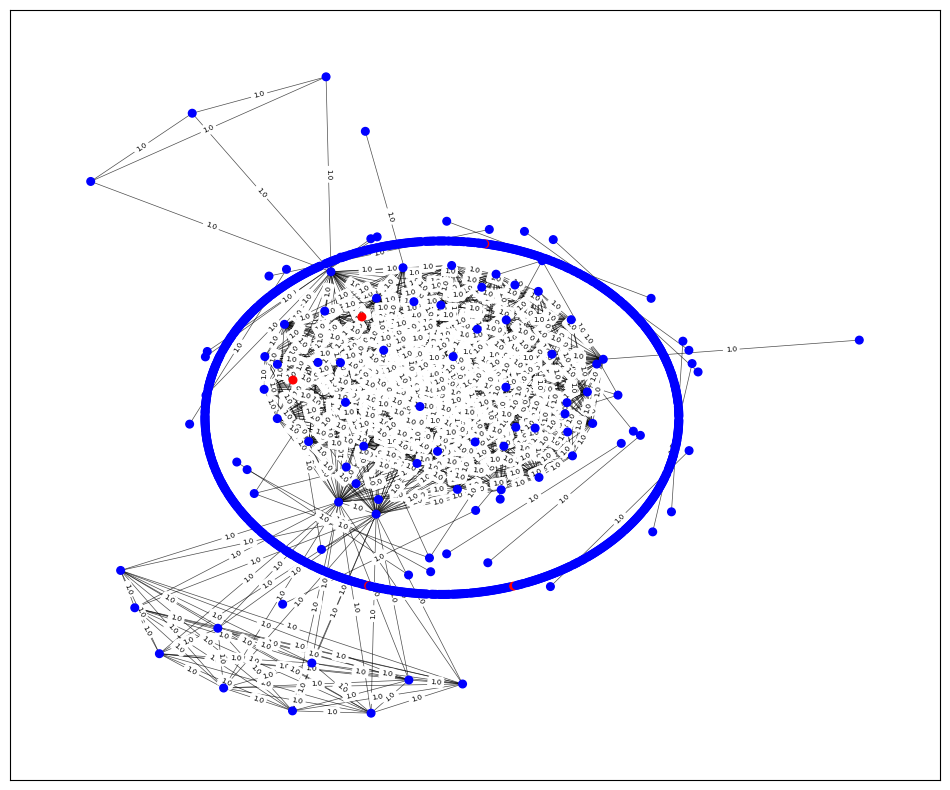

In [39]:
# Create a color map: assign one color to nodes with label 0, another to nodes with label 1
# Draw the graph using the color map
pos = nx.kamada_kawai_layout(G_sub) 
# pos = nx.spring_layout(G_sub,seed=42)# Use spring layout for better visual separation
# pos = nx.random_layout(G_sub) 


plt.figure(figsize=(12, 10))
node_options={"node_color":color_map, "node_size":30}
edge_options={"width": 0.5, "alpha":.7, "edge_color": "black"}
edge_labels = {(u, v): round(d['edge_weight'], 0) for u, v, d in G_sub.edges(data=True)}

nx.draw_networkx_nodes(G_sub, pos, **node_options)
nx.draw_networkx_edges(G_sub, pos, **edge_options)
nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, font_size=5)
plt.show()

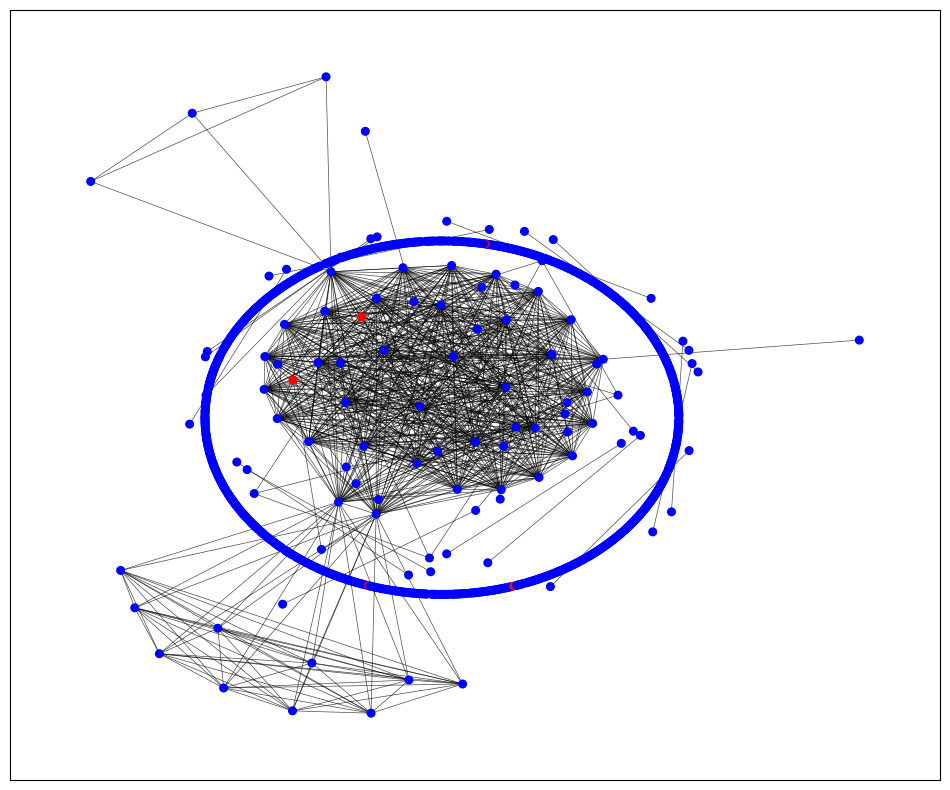

In [40]:
# Create a color map: assign one color to nodes with label 0, another to nodes with label 1
# Draw the graph using the color map
pos = nx.kamada_kawai_layout(G_sub) 
# pos = nx.spring_layout(G_sub,seed=42)# Use spring layout for better visual separation
# pos = nx.random_layout(G_sub) 


plt.figure(figsize=(12, 10))
node_options={"node_color":color_map, "node_size":30}
edge_options={"width": 0.5, "alpha":.7, "edge_color": "black"}
# edge_labels = {(u, v): round(d['edge_weight']/2, 1) for u, v, d in G_sub.edges(data=True)}

nx.draw_networkx_nodes(G_sub, pos, **node_options)
nx.draw_networkx_edges(G_sub, pos, **edge_options)
# nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, font_size=5)
plt.show()

In [41]:
from torch_geometric.utils import degree

edge_index = data.edge_index
num_nodes = data.num_nodes

# Calculate the degree of each node
node_degrees = degree(edge_index[0], num_nodes=num_nodes)
node_degrees

tensor([708.,   0.,   0.,  ...,   0.,   1.,   3.])

# 3 Implement algorithms on Claim Network

In [79]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 3.1 DOMINANT

In [80]:
data

Data(x=[19140, 29], edge_index=[2, 17853399], y=[19140], edge_weight=[17853399])

In [72]:
from pygod.detector import DOMINANT

model = DOMINANT(hid_dim=16,num_layers=4, epoch=100, batch_size= 64, dropout=0.7, lr=0.001, weight_decay=5e-4,sigmoid_s=True, contamination=0.01, save_emb =True, verbose=3)  # hyperparameters can be set here
model.fit(data)  # input data is a PyG data object

Epoch 0000: Loss 486.4951 |  | Time 51.83
Epoch 0001: Loss 396.2993 |  | Time 47.62
Epoch 0002: Loss 371.9192 |  | Time 48.58
Epoch 0003: Loss 364.6731 |  | Time 46.80
Epoch 0004: Loss 358.0296 |  | Time 46.39
Epoch 0005: Loss 354.2985 |  | Time 51.22
Epoch 0006: Loss 351.3145 |  | Time 47.85
Epoch 0007: Loss 350.0606 |  | Time 47.71
Epoch 0008: Loss 345.5344 |  | Time 48.12
Epoch 0009: Loss 344.2864 |  | Time 46.80
Epoch 0010: Loss 346.9380 |  | Time 47.33
Epoch 0011: Loss 344.4332 |  | Time 46.85
Epoch 0012: Loss 343.7964 |  | Time 47.99
Epoch 0013: Loss 341.7023 |  | Time 48.55
Epoch 0014: Loss 343.0013 |  | Time 47.68
Epoch 0015: Loss 342.3646 |  | Time 48.62
Epoch 0016: Loss 341.1035 |  | Time 47.59
Epoch 0017: Loss 338.8473 |  | Time 48.68
Epoch 0018: Loss 338.3619 |  | Time 48.34
Epoch 0019: Loss 340.2059 |  | Time 47.44
Epoch 0020: Loss 339.3838 |  | Time 47.96
Epoch 0021: Loss 338.0932 |  | Time 48.57
Epoch 0022: Loss 337.1007 |  | Time 48.67
Epoch 0023: Loss 337.9785 |  | Tim

DOMINANT(act=<function relu at 0x00000164DD8B2700>,
         backbone=<class 'torch_geometric.nn.models.basic_gnn.GCN'>,
         batch_size=64, compile_model=False, contamination=0.01,
         dropout=0.7, epoch=100, gpu=None, hid_dim=16, lr=0.001,
         num_layers=4, num_neigh=[-1, -1, -1, -1], save_emb=True,
         sigmoid_s=True, verbose=3, weight=0.5, weight_decay=0.0005)

In [73]:
model.emb.size()

torch.Size([19140, 16])

In [74]:
results=model.predict(data, return_score= True, return_emb=True)

Test: Loss 0.0702 |  | Time 28.25


In [75]:
y_pred, y_score, y_emb =results 

In [46]:

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
cm = confusion_matrix(y, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9801462904911181
Precision: 0.030303030303030304
Recall: 0.06060606060606061
Confusion Matrix:
 [[18752   256]
 [  124     8]]


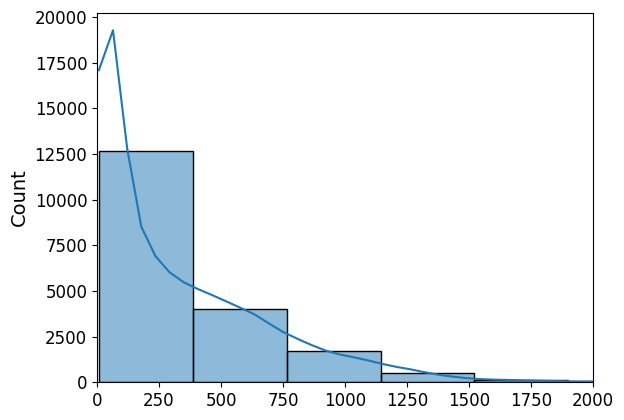

In [47]:


# Using seaborn's distplot for a more visual distribution plot
sns.histplot(y_score, kde=True, bins=30) 
plt.xlim(0, 2000) 
plt.show()

In [76]:
threshold=750
y_pred_1 = (y_score > threshold).int()  # Convert boolean to int (1 or 0)

# Display y_pred
print(y_pred_1)


tensor([0, 0, 0,  ..., 0, 0, 1], dtype=torch.int32)


In [77]:
accuracy = accuracy_score(y, y_pred_1)
precision = precision_score(y, y_pred_1, zero_division=0)
recall = recall_score(y, y_pred_1, zero_division=0)
cm = confusion_matrix(y, y_pred_1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8375130616509927
Precision: 0.01905684754521964
Recall: 0.44696969696969696
Confusion Matrix:
 [[15971  3037]
 [   73    59]]


ROC-AUC: 0.74


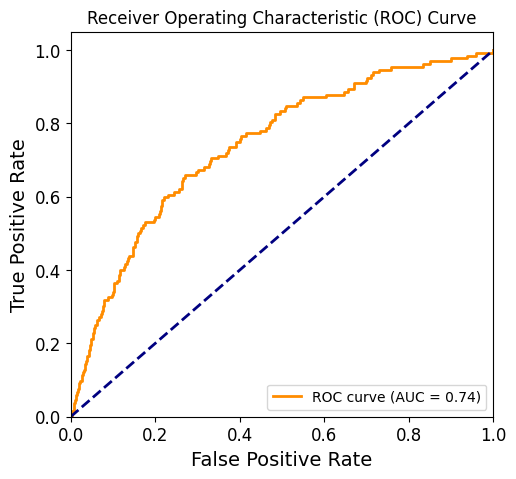

In [50]:

# ROC Curve
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# # PR curve
# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall (PR) Curve')
# plt.legend(loc="lower left")

# plt.tight_layout()
# plt.show()

### Cluster with OPTICS 

In [78]:
import numpy as np
from sklearn.cluster import OPTICS
# Create and fit the OPTICS model
x_cluster = y_emb.detach().numpy()
optics_model = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.001)
optics_model.fit(x_cluster)

c:\Users\s745998\AppData\Local\miniconda3\envs\mygraphenv\lib\site-packages\sklearn\cluster\_optics.py:995: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


OPTICS(min_cluster_size=0.001, min_samples=10)

In [79]:
# extract cluster labels
labels = optics_model.labels_
labels

array([-1, -1, -1, ..., -1, -1, -1])

In [80]:
# Get unique values and their counts
unique_values, counts = np.unique(labels, return_counts=True)

# Display results
for value, count in zip(unique_values, counts):
    print(f'Value: {value}, Count: {count}')

Value: -1, Count: 15512
Value: 0, Count: 35
Value: 1, Count: 32
Value: 2, Count: 30
Value: 3, Count: 33
Value: 4, Count: 23
Value: 5, Count: 24
Value: 6, Count: 22
Value: 7, Count: 27
Value: 8, Count: 837
Value: 9, Count: 28
Value: 10, Count: 36
Value: 11, Count: 29
Value: 12, Count: 31
Value: 13, Count: 33
Value: 14, Count: 30
Value: 15, Count: 23
Value: 16, Count: 20
Value: 17, Count: 26
Value: 18, Count: 27
Value: 19, Count: 27
Value: 20, Count: 28
Value: 21, Count: 25
Value: 22, Count: 28
Value: 23, Count: 21
Value: 24, Count: 23
Value: 25, Count: 20
Value: 26, Count: 19
Value: 27, Count: 24
Value: 28, Count: 29
Value: 29, Count: 33
Value: 30, Count: 20
Value: 31, Count: 24
Value: 32, Count: 25
Value: 33, Count: 39
Value: 34, Count: 76
Value: 35, Count: 19
Value: 36, Count: 24
Value: 37, Count: 25
Value: 38, Count: 20
Value: 39, Count: 36
Value: 40, Count: 35
Value: 41, Count: 19
Value: 42, Count: 21
Value: 43, Count: 31
Value: 44, Count: 24
Value: 45, Count: 38
Value: 46, Count: 1

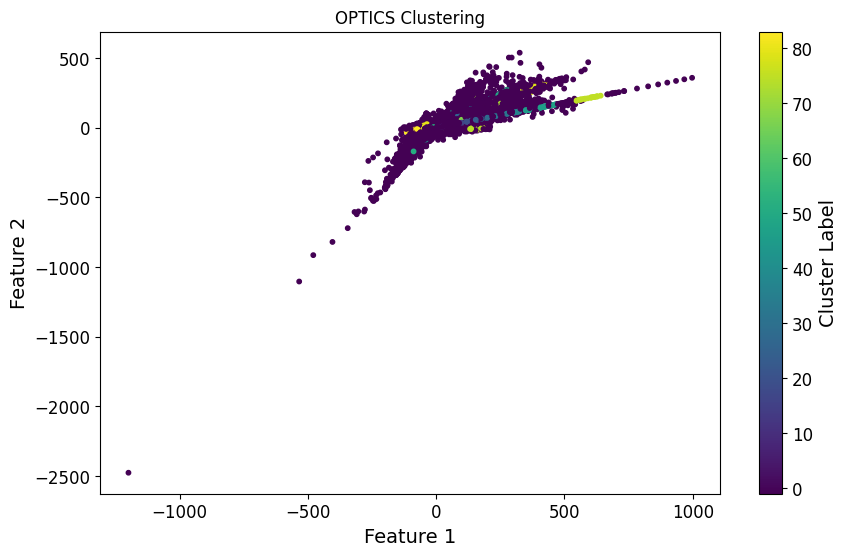

In [65]:
# Plotting the clusters
plt.figure(figsize=(10, 6))
plt.scatter(x_cluster[:, 8], x_cluster[:, 9], c=labels, cmap='viridis', marker='o', s=10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('OPTICS Clustering')
plt.colorbar(label='Cluster Label')
plt.show()

### 3.2 AnomalyDAE


In [32]:
from pygod.detector import AnomalyDAE

model_DAE = AnomalyDAE(num_layers=4, epoch=100, batch_size= 128, dropout=0.7, lr=0.0001, weight_decay=5e-4, contamination=0.01, save_emb =True, verbose=3)  # hyperparameters can be set here
model_DAE.fit(data)  # input data is a PyG data object

Epoch 0000: Loss 15876.2518 |  | Time 19.18
Epoch 0001: Loss 5063.4749 |  | Time 17.75
Epoch 0002: Loss 2353.0111 |  | Time 18.20
Epoch 0003: Loss 2319.2357 |  | Time 18.42
Epoch 0004: Loss 985.8027 |  | Time 17.84
Epoch 0005: Loss 747.5046 |  | Time 17.45
Epoch 0006: Loss 640.6091 |  | Time 20.40
Epoch 0007: Loss 603.8337 |  | Time 18.98
Epoch 0008: Loss 537.8124 |  | Time 18.90
Epoch 0009: Loss 550.5446 |  | Time 19.66
Epoch 0010: Loss 518.9221 |  | Time 19.16
Epoch 0011: Loss 504.8720 |  | Time 18.70
Epoch 0012: Loss 475.2317 |  | Time 19.58
Epoch 0013: Loss 469.0277 |  | Time 19.81
Epoch 0014: Loss 473.7053 |  | Time 18.77
Epoch 0015: Loss 451.6460 |  | Time 21.05
Epoch 0016: Loss 455.0428 |  | Time 19.73
Epoch 0017: Loss 446.9918 |  | Time 16.94
Epoch 0018: Loss 459.2483 |  | Time 15.56
Epoch 0019: Loss 444.7878 |  | Time 15.98
Epoch 0020: Loss 444.0628 |  | Time 15.27
Epoch 0021: Loss 444.7717 |  | Time 15.20
Epoch 0022: Loss 443.5362 |  | Time 15.24
Epoch 0023: Loss 443.9555 |  

AnomalyDAE(act=<function relu at 0x00000164554F3700>, alpha=0.5,
           backbone=None, batch_size=128, compile_model=False,
           contamination=0.01, dropout=0.7, emb_dim=64, epoch=100, eta=1.0,
           gpu=None, hid_dim=64, lr=0.0001, num_layers=4,
           num_neigh=[-1, -1, -1, -1], save_emb=True, theta=1.0, verbose=3,
           weight_decay=0.0005)

In [33]:
results=model_DAE.predict(data, return_score= True, return_emb=True)
y_pred, y_score, y_emb =results 

Test: Loss 1.2171 |  | Time 13.07


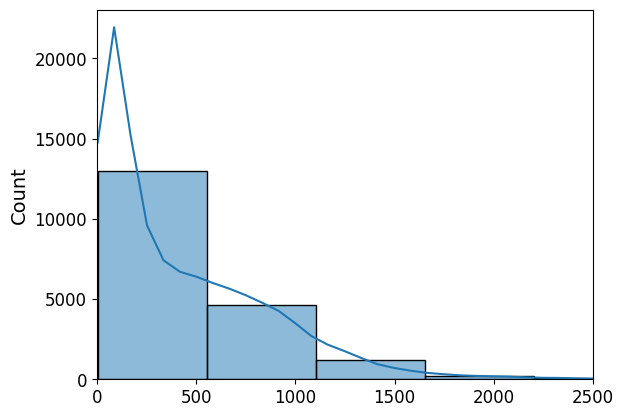

In [34]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(y_score, kde=True, bins=30) 
plt.xlim(0, 2500) 
plt.show()

In [37]:
threshold=1000
y_pred_1 = (y_score > threshold).int()  # Convert boolean to int (1 or 0)
accuracy = accuracy_score(y, y_pred_1)
precision = precision_score(y, y_pred_1, zero_division=0)
recall = recall_score(y, y_pred_1, zero_division=0)
cm = confusion_matrix(y, y_pred_1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8884012539184953
Precision: 0.01826923076923077
Recall: 0.2878787878787879
Confusion Matrix:
 [[16966  2042]
 [   94    38]]


ROC-AUC: 0.72


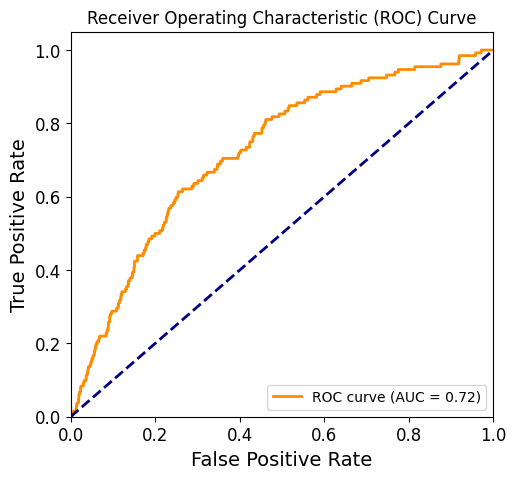

In [38]:
# ROC Curve
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# # PR curve
# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall (PR) Curve')
# plt.legend(loc="lower left")

# plt.tight_layout()
# plt.show()

### Manually implemented

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data

# Model Definition
class Encoder(nn.Module):
    def __init__(self, nfeat, nhid, dropout):
        super(Encoder, self).__init__()
        self.gc1 = GCNConv(nfeat, nhid)
        self.gc2 = GCNConv(nhid, nhid)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.gc1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.gc2(x, edge_index, edge_weight))
        return x

class Attribute_Decoder(nn.Module):
    def __init__(self, nfeat, nhid, dropout):
        super(Attribute_Decoder, self).__init__()
        self.gc1 = GCNConv(nhid, nhid)
        self.gc2 = GCNConv(nhid, nfeat)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.gc1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gc2(x, edge_index, edge_weight)
        return x

class Structure_Decoder(nn.Module):
    def __init__(self, nhid, dropout):
        super(Structure_Decoder, self).__init__()
        self.gc1 = GCNConv(nhid, nhid)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.gc1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.matmul(x, x.t())
        return x

class Dominant(nn.Module):
    def __init__(self, feat_size, hidden_size, dropout):
        super(Dominant, self).__init__()
        self.shared_encoder = Encoder(feat_size, hidden_size, dropout)
        self.attr_decoder = Attribute_Decoder(feat_size, hidden_size, dropout)
        self.struct_decoder = Structure_Decoder(hidden_size, dropout)
    
    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_weight
        # Encode
        x_encoded = self.shared_encoder(x, edge_index, edge_weight)
        # Decode feature matrix
        x_hat = self.attr_decoder(x_encoded, edge_index, edge_weight)
        # Decode adjacency matrix
        struct_reconstructed = self.struct_decoder(x_encoded, edge_index, edge_weight)
        # Return reconstructed matrices
        return struct_reconstructed, x_hat

In [45]:
def train_model(data, num_epochs=200, hidden_size=16, dropout=0.7, learning_rate=0.01, weight_decay=5e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    # Initialize model
    feat_size = data.x.shape[1]
    model = Dominant(feat_size=feat_size, hidden_size=hidden_size, dropout=dropout).to(device)

    # Define optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Define loss functions
    # Attribute reconstruction loss (MSE Loss)
    attr_criterion = nn.MSELoss()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        struct_reconstructed, x_hat = model(data)
        
        # Attribute reconstruction loss
        attr_loss = attr_criterion(x_hat, data.x)
        
        # Structure reconstruction loss
        # Use negative sampling for efficiency
        pos_edge_index = data.edge_index
        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index, num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1)
        )

        # Scores for positive edges
        pos_scores = struct_reconstructed[pos_edge_index[0], pos_edge_index[1]]
        # Scores for negative edges
        neg_scores = struct_reconstructed[neg_edge_index[0], neg_edge_index[1]]

        # Labels for edges
        pos_labels = torch.ones(pos_scores.size(0), device=device)
        neg_labels = torch.zeros(neg_scores.size(0), device=device)

        # Combine scores and labels
        scores = torch.cat([pos_scores, neg_scores], dim=0)
        labels = torch.cat([pos_labels, neg_labels], dim=0)

        # Structure reconstruction loss (Binary Cross-Entropy Loss)
        # struct_loss = F.binary_cross_entropy_with_logits(scores, labels)
        # Structure reconstruction loss (MSE Loss)
        struct_criterion = nn.MSELoss()
        struct_loss = struct_criterion(scores, labels)

        # Total loss
        loss = attr_loss + struct_loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.2f}, Struct loss: {struct_loss.item():.2f}, attr loss:{attr_loss.item():.2f}')

    return model

In [125]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data

# Model Definition
class Encoder(nn.Module):
    def __init__(self, nfeat, nhid, dropout):
        super(Encoder, self).__init__()
        self.gc1 = GCNConv(nfeat, nhid)
        self.gc2 = GCNConv(nhid, nhid)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.gc1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.gc2(x, edge_index, edge_weight))
        return x

class Attribute_Decoder(nn.Module):
    def __init__(self, nfeat, nhid, dropout):
        super(Attribute_Decoder, self).__init__()
        self.gc1 = GCNConv(nhid, nhid)
        self.gc2 = GCNConv(nhid, nfeat)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.gc1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gc2(x, edge_index, edge_weight)
        return x

class Structure_Decoder(nn.Module):
    def __init__(self, nhid, dropout):
        super(Structure_Decoder, self).__init__()
        self.gc1 = GCNConv(nhid, nhid)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.gc1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.matmul(x, x.t())
        return x

In [126]:
class Dominant(nn.Module):
    def __init__(self, feat_size, hidden_size, dropout):
        super(Dominant, self).__init__()
        self.shared_encoder = Encoder(feat_size, hidden_size, dropout)
        self.attr_decoder = Attribute_Decoder(feat_size, hidden_size, dropout)
        self.struct_decoder = Structure_Decoder(hidden_size, dropout)
    
    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_weight
        # Encode
        x_encoded = self.shared_encoder(x, edge_index, edge_weight)
        # Decode feature matrix
        x_hat = self.attr_decoder(x_encoded, edge_index, edge_weight)
        # Decode adjacency matrix
        struct_reconstructed = self.struct_decoder(x_encoded, edge_index, edge_weight)
        # Return reconstructed matrices
        return struct_reconstructed, x_hat, x_encoded

    def predict(self, data, get_emb=False):
        self.eval()
        with torch.no_grad():
            struct_reconstructed, x_hat, x_encoded = self(data)

            # Attribute Reconstruction Error
            attr_errors = torch.sqrt(torch.mean((x_hat - data.x) ** 2, dim=1))

            # Structure Reconstruction Error
            adj_true = torch.zeros(data.num_nodes, data.num_nodes, device='cpu')
            adj_true[data.edge_index[0], data.edge_index[1]] = 1
            struct_errors = torch.sqrt(torch.mean((struct_reconstructed - adj_true) ** 2, dim=1))

            # Total Anomaly Score
            anomaly_scores = attr_errors + struct_errors
            if get_emb == True:
                return anomaly_scores, x_encoded
            else:
                return anomaly_scores

    def train_model(self, data, num_epochs=200, learning_rate=0.01, weight_decay=5e-4):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        data = data.to(device)
        self.to(device)

        # Define optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # Define loss functions
        # Attribute reconstruction loss (MSE Loss)
        attr_criterion = nn.MSELoss()
        struct_criterion = nn.MSELoss()

        # Training loop
        for epoch in range(num_epochs):
            self.train()
            optimizer.zero_grad()
            
            # Forward pass
            struct_reconstructed, x_hat, x_encoded = self(data)
            
            # Attribute reconstruction loss
            attr_loss = attr_criterion(x_hat, data.x)
            
            # Structure reconstruction loss
            # Use negative sampling for efficiency
            pos_edge_index = data.edge_index
            neg_edge_index = negative_sampling(
                edge_index=pos_edge_index, num_nodes=data.num_nodes,
                num_neg_samples=pos_edge_index.size(1)
            )

            # Create adjacency matrix labels
            adj_matrix = torch.zeros((data.num_nodes, data.num_nodes), device=device)
            adj_matrix[pos_edge_index[0], pos_edge_index[1]] = 1
            adj_matrix[neg_edge_index[0], neg_edge_index[1]] = 0

            # Structure reconstruction loss (MSE Loss)
            struct_loss = struct_criterion(struct_reconstructed, adj_matrix)

            # Total loss
            loss = 1000 * attr_loss + struct_loss

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.2f}, Struct loss: {struct_loss.item():.2f}, Attr loss: {attr_loss.item():.2f}')

        return self

In [127]:
# Initialize model
model = Dominant(feat_size=data.x.shape[1], hidden_size=16, dropout=0.8)
model.train_model(data, num_epochs=200, learning_rate=0.02, weight_decay=5e-4)

Epoch 1/200, Loss: 525163560960.00, Struct loss: 525046185984.00, Attr loss: 117372.21
Epoch 2/200, Loss: 81966989312.00, Struct loss: 81888116736.00, Attr loss: 78871.63
Epoch 3/200, Loss: 19476985856.00, Struct loss: 19407034368.00, Attr loss: 69951.91
Epoch 4/200, Loss: 11988253696.00, Struct loss: 11925687296.00, Attr loss: 62566.34
Epoch 5/200, Loss: 2541641216.00, Struct loss: 2477094144.00, Attr loss: 64547.02
Epoch 6/200, Loss: 773416576.00, Struct loss: 715719808.00, Attr loss: 57696.77
Epoch 7/200, Loss: 259621056.00, Struct loss: 202628496.00, Attr loss: 56992.56
Epoch 8/200, Loss: 162575680.00, Struct loss: 106168208.00, Attr loss: 56407.48
Epoch 9/200, Loss: 115977776.00, Struct loss: 60031768.00, Attr loss: 55946.01
Epoch 10/200, Loss: 77197440.00, Struct loss: 21625568.00, Attr loss: 55571.87
Epoch 11/200, Loss: 74897200.00, Struct loss: 19547302.00, Attr loss: 55349.90
Epoch 12/200, Loss: 69449264.00, Struct loss: 14134281.00, Attr loss: 55314.98
Epoch 13/200, Loss: 693

Dominant(
  (shared_encoder): Encoder(
    (gc1): GCNConv(29, 16)
    (gc2): GCNConv(16, 16)
  )
  (attr_decoder): Attribute_Decoder(
    (gc1): GCNConv(16, 16)
    (gc2): GCNConv(16, 29)
  )
  (struct_decoder): Structure_Decoder(
    (gc1): GCNConv(16, 16)
  )
)

In [149]:
# # Evaluation Mode
# def predict(model, data):
#     model.eval()
#     with torch.no_grad():
#         struct_reconstructed, x_hat = model(data)

#         # Attribute Reconstruction Error
#         attr_errors = torch.mean((x_hat - data.x) ** 2, dim=1)

#         # Structure Reconstruction Error
#         adj_true = torch.zeros(data.num_nodes, data.num_nodes, device='cpu')
#         adj_true[data.edge_index[0], data.edge_index[1]] = 1
#         struct_errors = torch.mean((struct_reconstructed - adj_true) ** 2, dim=1)

#         # Total Anomaly Score
#         anomaly_scores = attr_errors + struct_errors
#         return anomaly_scores
anomaly_scores, y_emb=model.predict(data, get_emb=True)

In [139]:
y_score = anomaly_scores.numpy()
y_score = pd.Series(y_score, name='y_score')
y_real= pd.Series(all_nodes_df['investigation_flag'], name='y')
triage = pd.Series(all_nodes_df['triage_flag'], name='triage_flag')

In [142]:
combined_df = pd.concat([y_score.reset_index(drop=True), y_real.reset_index(drop=True), triage.reset_index(drop=True)], axis=1)
threshold = 500
combined_df['y_pred'] = np.where(combined_df['y_score'] >= threshold, 1, 0)
combined_df

,y_score,y,triage_flag,y_pred
0,34.610,0,0,0
1,51.587,0,0,0
2,16.868,0,0,0
3,37.056,0,0,0
4,33.463,0,0,0
...,...,...,...,...
19135,90.006,0,0,0
19136,141.166,0,0,0
19137,20.351,0,0,0
19138,30.059,0,0,0


In [146]:
inv_curr = sum(combined_df['y'])
triage_curr = sum(combined_df['triage_flag'])

t2i_curr = np.divide(inv_curr, triage_curr,
                        out=np.zeros_like(inv_curr, dtype=float), where=triage_curr != 0)

inv_pred = sum(combined_df[combined_df['y_pred'] == 1]['y'])
triage_pred = sum(combined_df[combined_df['y_pred'] == 1]['triage_flag'])

t2i_pred = np.divide(inv_pred, triage_pred,
                        out=np.zeros_like(inv_pred, dtype=float), where=triage_pred != 0)

print(f"original t2i is {t2i_curr: .4f}, predicted t2i is {t2i_pred: .4f}")



original t2i is  0.1002, predicted t2i is  0.2963


In [144]:
alert_vol= sum(combined_df['y_pred'] == 1)
alert_vol

360

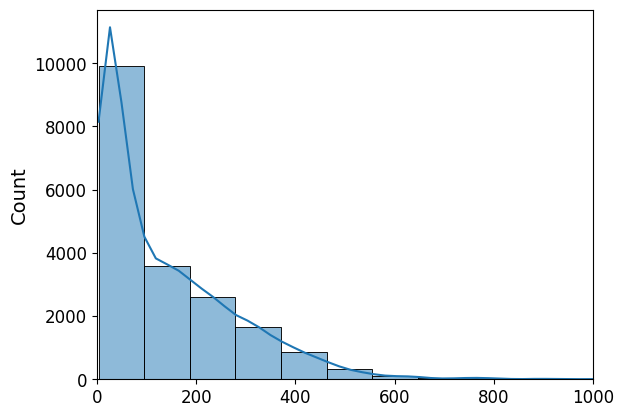

In [145]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(anomaly_scores, kde=True, bins=50) 
plt.xlim(0,1000) 
plt.show()

In [148]:
threshold=500
y_pred_1 = (anomaly_scores >= threshold).int()  # Convert boolean to int (1 or 0)

# Display y_pred
print(y_pred_1)
accuracy = accuracy_score(y, y_pred_1)
precision = precision_score(y, y_pred_1, zero_division=0)
recall = recall_score(y, y_pred_1, zero_division=0)
cm = confusion_matrix(y, y_pred_1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)

tensor([0, 0, 0,  ..., 0, 0, 0], dtype=torch.int32)
Accuracy: 0.9751306165099268
Precision: 0.022222222222222223
Recall: 0.06060606060606061
Confusion Matrix:
 [[18656   352]
 [  124     8]]


ROC-AUC: 0.73


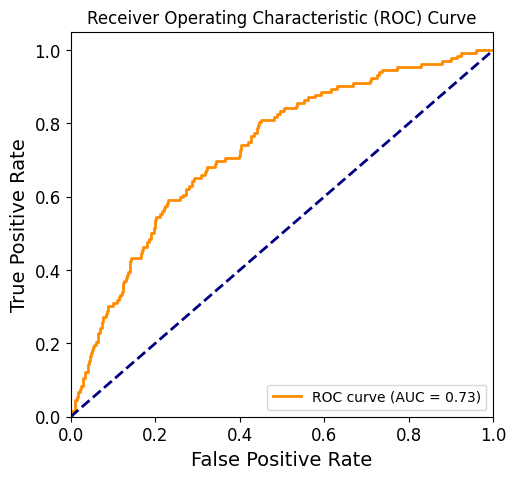

In [101]:
# ROC Curve
y_score=anomaly_scores
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# # PR curve
# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall (PR) Curve')
# plt.legend(loc="lower left")

# plt.tight_layout()
# plt.show()

In [102]:
# Identify Top-K Anomalous Nodes
topk = int(data.x.size(0)*0.01)  # Adjust as needed
_, topk_indices = torch.topk(anomaly_scores, k=topk, largest=True)
print(f'Top-{topk} anomalous nodes: {topk_indices}')

Top-191 anomalous nodes: tensor([12104, 14056, 15794, 16807, 11863, 16895, 12970,  4727,  8381,  4741,
        12404, 10488, 12535, 10852, 17287,  5128,  4106, 10347,  8782,  1002,
        13669, 18234,  6860, 10990, 13449, 17589,  3320, 11328, 13787, 17095,
        18438,  6005, 17164, 15330,  9759, 13015,  5299,   725,  4790,  1141,
         8918, 14051, 17733, 16782,  5016, 14348,  6451, 11641,  6916, 18049,
        13567, 15081, 15711,  2866,  6103,  8558,  9583, 12365, 15758, 11406,
          582,  9239, 12284,  7553,  1502,  7474, 18706, 13614, 18953,  6997,
         9569, 12265,  9740,  2430, 16487,    21,  7572, 11349,  7310, 14819,
         5309,  3619,   320,  6206,  2588,  7991, 14309,   562,  4157, 11025,
        13044, 19084,  7497,  8118,  9499,  2823, 13124,  4866,  4781, 15925,
         8858,  4834,  1316, 16101, 16457,  3432, 12054, 12437,  7647,  6070,
        16791,  2722,  4585,  7168, 15491, 12652,  2898,  8235, 17464,  2387,
        10881,   700,  3314,  3898,  80

In [103]:
# Invert the mapping to get indices back to node IDs
idx_to_node_id = {idx: node_id for node_id, idx in node_id_to_idx.items()}

# Now, get the node IDs of the top-K anomalous nodes
topk_node_ids = [idx_to_node_id[idx.item()] for idx in topk_indices]

print(f'Top-{topk} anomalous node IDs: {topk_node_ids}')

Top-191 anomalous node IDs: ['NWRTP2102556', 'NWRTP2201691', 'NWRTP2300643', 'NWRTP2301661', 'NWRTP2102314', 'NWRTP2301749', 'NWRTP2200602', 'NWRTP1901482', 'NWRTP2001744', 'NWRTP1901496', 'NWRTP2200036', 'NWRTP2100936', 'NWRTP2200167', 'NWRTP2101301', 'NWRTP2302144', 'NWRTP1901914', 'NWRTP1900804', 'NWRTP2100795', 'NWRTP2002146', 'NWRND2200153', 'NWRTP2201302', 'NWRTP2303093', 'NWRTP2000198', 'NWRTP2101439', 'NWRTP2201081', 'NWRTP2302447', 'NWRTP1803102', 'NWRTP2101779', 'NWRTP2201421', 'NWRTP2301950', 'NWRTP2400102', 'NWRTP1902862', 'NWRTP2302019', 'NWRTP2300178', 'NWRTP2100203', 'NWRTP2200647', 'NWRTP1902095', 'NWRND2100113', 'NWRTP1901550', 'NWRND2300010', 'NWRTP2002297', 'NWRTP2201686', 'NWRTP2302591', 'NWRTP2301636', 'NWRTP1901795', 'NWRTP2201985', 'NWRTP1903331', 'NWRTP2102092', 'NWRTP2000255', 'NWRTP2302907', 'NWRTP2201200', 'NWRTP2202719', 'NWRTP2300559', 'NWRTP1802607', 'NWRTP1902970', 'NWRTP2001921', 'NWRTP2100027', 'NWRTP2102818', 'NWRTP2300607', 'NWRTP2101857', 'NWRND20001

### Claim Clustering 

In [154]:
import numpy as np
from sklearn.cluster import OPTICS
# Create and fit the OPTICS model
x_cluster = y_emb.detach().numpy()
optics_model = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.01)
optics_model.fit(x_cluster)

c:\Users\s745998\AppData\Local\miniconda3\envs\mygraphenv\lib\site-packages\sklearn\cluster\_optics.py:995: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


OPTICS(min_cluster_size=0.01, min_samples=10)

In [155]:
# extract cluster labels
labels = optics_model.labels_
labels

array([-1, -1, -1, ..., -1, -1, -1])

In [156]:
# Get unique values and their counts
unique_values, counts = np.unique(labels, return_counts=True)

# Display results
for value, count in zip(unique_values, counts):
    print(f'Value: {value}, Count: {count}')

Value: -1, Count: 17966
Value: 0, Count: 248
Value: 1, Count: 271
Value: 2, Count: 209
Value: 3, Count: 207
Value: 4, Count: 239


In [176]:
#Calculate Node Degrees
from torch_geometric.utils import degree

edge_index = data.edge_index
num_nodes = data.num_nodes

# Calculate the degree of each node
node_degrees = degree(edge_index[0], num_nodes=num_nodes)


In [177]:
degree_np= node_degrees.numpy()

In [178]:
# Use the cluster labels to group nodes into clusters and compute their respective degrees
from collections import defaultdict

# Convert cluster_labels to a tensor
cluster_labels = labels

# Create a dictionary to store node degrees for each cluster
cluster_degrees = defaultdict(list)

cluster_indices = defaultdict(list)

# Iterate over all nodes and add their degrees to the corresponding cluster
for node_idx in range(num_nodes):
    cluster_label = cluster_labels[node_idx].item()
    cluster_degrees[cluster_label].append(node_degrees[node_idx].item())
    cluster_indices[cluster_label].append(node_idx)

In [179]:
average_degrees = {}
for cluster_label, degrees in cluster_degrees.items():
    average_degrees[cluster_label] = sum(degrees) / len(degrees) if len(degrees) > 0 else 0

# Print or use the average degrees as needed
for cluster_label, avg_degree in average_degrees.items():
    print(f'Average degree of cluster {cluster_label}: {avg_degree:.2f}')


Average degree of cluster -1: 7.74
Average degree of cluster 1: 641.00
Average degree of cluster 2: 0.18
Average degree of cluster 3: 0.11
Average degree of cluster 4: 170.28
Average degree of cluster 0: 641.00


In [188]:
node_degrees.sum().item()/node_degrees.size()[0]

26.776280041797282

In [189]:
combined_df

,y_score,y,triage_flag,y_pred
0,34.610,0,0,0
1,51.587,0,0,0
2,16.868,0,0,0
3,37.056,0,0,0
4,33.463,0,0,0
...,...,...,...,...
19135,90.006,0,0,0
19136,141.166,0,0,0
19137,20.351,0,0,0
19138,30.059,0,0,0
